# Notebook 11: Decision Faithfulness Dashboard

Dashboard/view layer over saved artifacts. It prefers benchmark-emitted backend recommendation metadata when available and keeps exploratory WHT hidden by default.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

try:
    from notebooks._helpers import (
        repo_root,
        load_metrics_master,
        load_quality_cost_master,
        load_quality_cost_unavailable,
        load_run_manifest,
        ensure_run_status_norm,
        parse_metric_availability,
        ensure_optional_columns,
        unavailable_panel_table,
        placeholder_plot,
    )
except ModuleNotFoundError:
    from _helpers import (
        repo_root,
        load_metrics_master,
        load_quality_cost_master,
        load_quality_cost_unavailable,
        load_run_manifest,
        ensure_run_status_norm,
        parse_metric_availability,
        ensure_optional_columns,
        unavailable_panel_table,
        placeholder_plot,
    )

from src.notebook_utils import FilterPipeline, EXACT_REFERENCE_ENCODINGS

ROOT = repo_root()

pd.set_option("display.max_columns", 160)



In [2]:
run_manifest = load_run_manifest(ROOT / "results", required=False)
all_df = load_metrics_master(ROOT / "results", required=False)
comparable_df = load_quality_cost_master(ROOT / "results", required=False)
quality_unavailable_df = load_quality_cost_unavailable(ROOT / "results", required=False)
include_exploratory_wht = False

benchmark_paths = sorted((ROOT / "results").glob("benchmark_*feat.json"))
recommendation_rows = []
for benchmark_path in benchmark_paths:
    try:
        record = json.loads(benchmark_path.read_text())
    except Exception:
        continue
    if not isinstance(record, dict):
        continue
    rec = record.get("encoding_backend_recommendation", {})
    problem = record.get("problem", {})
    recommendation_rows.append({
        "instance_id": f"P{problem.get('n_features')}" if problem.get("n_features") is not None else None,
        "status": rec.get("status"),
        "formal_verdict": rec.get("formal_verdict"),
        "default_reviewer_backend": rec.get("default_reviewer_backend"),
        "reason": rec.get("reason"),
    })
recommendation_df = pd.DataFrame(recommendation_rows)

# Status/availability summaries are sourced from metrics_master + run_manifest only.
all_df = ensure_optional_columns(
    all_df,
    object_defaults={"metric_availability": "{}"},
)
all_df["metric_availability_dict"] = all_df["metric_availability"].apply(parse_metric_availability)
all_df = ensure_run_status_norm(all_df)

# Comparable panels are sourced only from quality_cost_master.
if not comparable_df.empty:
    comparable_df = ensure_run_status_norm(comparable_df)
    comparable_df = ensure_optional_columns(
        comparable_df,
        numeric_cols=["qubits", "gates", "depth"],
        object_defaults={
            "resource_status": "unavailable",
            "resource_confidence": np.nan,
            "resource_comparability_basis": np.nan,
        },
    )



## Shared Metric Panel Across Encoding Backends


In [3]:
focus = comparable_df.copy()
# Metrics that are part of the quality_cost_master schema
# (See src/report_schema.py for the schema definition)
# Note: top1_regret, optimum_recall_at_k, best_top_G_sampled_F are in metrics_master but not quality_cost_master
shared_panel_metrics = [
    "spearman_rho_F_G",
    "retained_energy_eta",
    "topk_regret",
    "best_F",
    "decision_distortion",
]

# Additional metrics available in metrics_master but not in quality_cost_master
additional_metrics_in_metrics_master = [
    "top1_regret",
    "optimum_recall_at_k", 
    "best_top_G_sampled_F",
    "best_sampled_F",
    "best_sampled_G",
]

if not focus.empty and "encoding" in focus.columns and not include_exploratory_wht:
    pipe = FilterPipeline(focus, label="faithfulness_input")
    pipe = pipe.filter_encoding(EXACT_REFERENCE_ENCODINGS)
    focus = pipe.result()

if not focus.empty and "encoding" in focus.columns:
    focus["encoding_order"] = focus["encoding"].map({"ilp_derived_exact": 0, "ilp_derived": 0}).fillna(1)
    focus = focus.sort_values(["encoding_order", "encoding"]).drop(columns=["encoding_order"])

if focus.empty:
    display(unavailable_panel_table(
        panel="Shared metric panel",
        reason="No comparable rows remain after applying reviewer-facing encoding filters.",
    ))
    panel_df = pd.DataFrame()
else:
    rows = []
    encodings = list(dict.fromkeys(focus["encoding"].dropna().tolist())) if "encoding" in focus.columns else ["all"]
    for encoding in encodings:
        sub = focus[focus["encoding"] == encoding] if ("encoding" in focus.columns and encoding != "all") else focus
        total = int(len(sub))
        for metric in shared_panel_metrics:
            if metric in sub.columns:
                vals = pd.to_numeric(sub[metric], errors="coerce")
            else:
                vals = pd.Series([np.nan] * total, index=sub.index, dtype=float)
            available = int(vals.notna().sum())
            rows.append({
                "encoding": encoding,
                "metric": metric,
                "availability": f"{available}/{total}",
                "mean_or_unavailable": ("unavailable" if available == 0 else float(vals.mean())),
                "median_or_unavailable": ("unavailable" if available == 0 else float(vals.median())),
                "status": ("available" if available > 0 else "unavailable"),
                "reason": ("present_with_nulls" if available > 0 else "metric_column_missing"),
            })
    panel_df = pd.DataFrame(rows)
    display(panel_df)
    display(Markdown(f"*Note: Additional quality metrics ({', '.join(additional_metrics_in_metrics_master)}) are available in `metrics_master` for deeper analysis.*"))

,encoding,metric,availability,mean_or_unavailable,median_or_unavailable,status,reason
0,ilp_derived_exact,spearman_rho_F_G,6/6,1.0,1.0,available,present_with_nulls
1,ilp_derived_exact,retained_energy_eta,6/6,1.0,1.0,available,present_with_nulls
2,ilp_derived_exact,topk_regret,6/6,0.0,0.0,available,present_with_nulls
3,ilp_derived_exact,best_F,6/6,600.0,600.0,available,present_with_nulls
4,ilp_derived_exact,decision_distortion,6/6,0.0,0.0,available,present_with_nulls


*Note: Additional quality metrics (top1_regret, optimum_recall_at_k, best_top_G_sampled_F, best_sampled_F, best_sampled_G) are available in `metrics_master` for deeper analysis.*

## Faithfulness vs Decision Quality


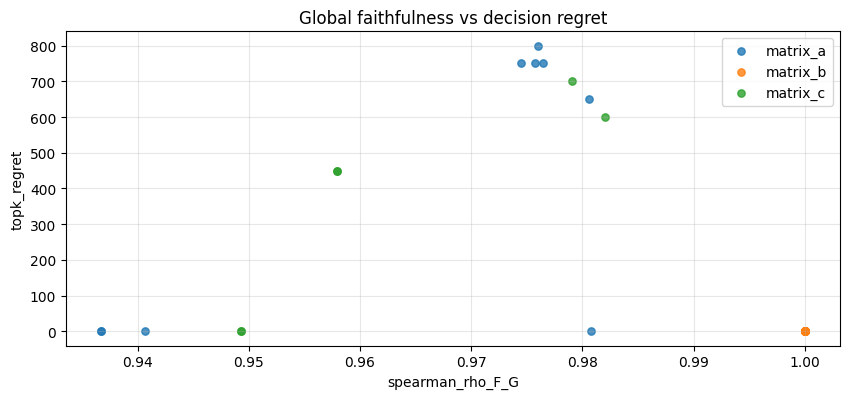

,matrix,stage,instance_id,family,encoding,decoder,alpha_mode,execution_mode,spearman_rho_F_G,topk_regret,best_F,decision_distortion
32,matrix_a,benchmark_matrix,P5,P,wht_truncated,bp1,paper,mixture,0.976039,800,3000,0.000000
3,matrix_a,benchmark_matrix,P4,P,wht_truncated,bp1,paper,mixture,0.974485,750,2800,0.000000
11,matrix_a,benchmark_matrix,P4,P,wht_truncated,bp1,heuristic,mixture,0.976464,750,2800,0.000000
21,matrix_a,benchmark_matrix,P4,P,wht_truncated,bp1,uniform,mixture,0.975730,750,2800,0.000000
7,matrix_c,benchmark_matrix,P5,P,wht_truncated_pricing,bp1,paper,mixture,0.979032,700,2500,0.166667
0,matrix_a,benchmark_matrix,P5,P,wht_truncated,bp1,uniform,mixture,0.980566,650,2900,0.033333
23,matrix_c,benchmark_matrix,P5,P,wht_truncated_pricing,bp1,uniform,mixture,0.982016,600,2500,0.166667
16,matrix_c,benchmark_matrix,P4,P,wht_truncated_pricing,bp1,paper,mixture,0.957893,450,2800,0.000000
18,matrix_c,benchmark_matrix,P4,P,wht_truncated_pricing,bp1,uniform,mixture,0.957930,450,2800,0.000000


In [4]:
ok = comparable_df.copy()

if ok.empty:
    display(unavailable_panel_table(
        panel="Faithfulness vs quality",
        reason="No comparable rows in quality_cost_master.",
    ))
else:
    has_xy = ok[ok["spearman_rho_F_G"].notna() & ok["topk_regret"].notna()].copy() if {"spearman_rho_F_G", "topk_regret"}.issubset(ok.columns) else pd.DataFrame()
    if has_xy.empty:
        fig, _ax = placeholder_plot("Faithfulness vs top-k regret", "`spearman_rho_F_G` or `topk_regret` unavailable.")
        display(fig)
        plt.close(fig)
    else:
        fig, ax = plt.subplots(figsize=(8.6, 4.1))
        if "matrix" in has_xy.columns:
            for matrix_name, sub in has_xy.groupby("matrix"):
                ax.scatter(sub["spearman_rho_F_G"], sub["topk_regret"], alpha=0.8, s=28, label=matrix_name)
            ax.legend(loc="best")
        else:
            ax.scatter(has_xy["spearman_rho_F_G"], has_xy["topk_regret"], alpha=0.8, s=28)
        ax.set_xlabel("spearman_rho_F_G")
        ax.set_ylabel("topk_regret")
        ax.set_title("Global faithfulness vs decision regret")
        ax.grid(alpha=0.3)
        fig.tight_layout()
        display(fig)
        plt.close(fig)

    # tension analysis: high faithfulness with non-zero regret
    # Note: top1_regret is not in quality_cost_master, so we only use topk_regret
    tension = ok[
        ok["spearman_rho_F_G"].ge(0.9)
        & (ok["topk_regret"].fillna(0).gt(0))
    ].copy() if {"spearman_rho_F_G", "topk_regret"}.issubset(ok.columns) else pd.DataFrame()

    if tension.empty:
        display(unavailable_panel_table(
            panel="High faithfulness + poor quality case",
            reason="No rows satisfy rho>=0.9 with non-zero topk_regret in current comparable artifacts.",
        ))
    else:
        # Only show columns that are in quality_cost_master
        show_cols = [
            "matrix", "stage", "instance_id", "family", "encoding", "decoder", "alpha_mode", "execution_mode",
            "spearman_rho_F_G", "topk_regret", "best_F", "decision_distortion",
        ]
        present = [c for c in show_cols if c in tension.columns]
        missing = [c for c in show_cols if c not in tension.columns]
        display(tension.sort_values(["topk_regret"], ascending=False)[present].head(12))
        if missing:
            display(unavailable_panel_table(
                panel="High faithfulness + poor quality case",
                reason="Some requested columns are unavailable for this panel.",
                details=", ".join(missing),
            ))

## Unavailable / Skipped Cases


In [5]:
# Filter out planned placeholder rows (unexecuted configurations with different seeds)
# These inflate unavailable counts without adding interpretive value
executed_df = all_df[~all_df["run_id"].str.startswith("planned::", na=False)].copy() if not all_df.empty else pd.DataFrame()

status_cols = [
    c for c in [
        "matrix", "run_id", "instance_id", "encoding", "decoder", "alpha_mode", "execution_mode", 
        "run_status", "run_status_norm", "status_reason_code", "run_error"
    ] if c in executed_df.columns
]
skipped = executed_df[executed_df["run_status_norm"] != "completed"][status_cols].copy() if (not executed_df.empty and "run_status_norm" in executed_df.columns) else pd.DataFrame()

# Categorize unavailability by type for clearer reporting
if not skipped.empty and "status_reason_code" in skipped.columns:
    # Add category labels
    def categorize_unavailability(row):
        reason = str(row.get("status_reason_code", ""))
        status = str(row.get("run_status_norm", ""))
        
        if status == "not_applicable":
            if "zero_decodable_syndromes" in reason:
                return "structural_boundary"
            elif "oracle_tiny_cap" in reason:
                return "structural_boundary"
            elif reason == "not_applicable":
                return "expected_unavailable"
            else:
                return "not_applicable"
        elif status == "unavailable":
            if "decoder_not_implemented" in str(row.get("run_error", "")):
                return "decoder_not_implemented"
            elif "upstream" in reason:
                return "dependency_issue"
            else:
                return "unavailable"
        elif status == "failed":
            return "execution_failure"
        else:
            return "other"
    
    skipped["unavailability_category"] = skipped.apply(categorize_unavailability, axis=1)
    
    display(Markdown("### Unavailable/Skipped Cases by Category (Planned placeholders filtered out)"))
    category_summary = skipped["unavailability_category"].value_counts().rename("count").reset_index()
    category_summary.columns = ["category", "count"]
    display(category_summary)
    
    display(Markdown(f"### Detailed Breakdown (first 10 of {len(skipped)} rows)"))
    display(skipped.head(10))
else:
    if not skipped.empty:
        display(skipped.head(10))

# Locked Stage E transparency card: driven only by quality_cost_unavailable.
display(Markdown("### Stage E Quality/Cost Unavailable Summary"))
if quality_unavailable_df.empty:
    display(unavailable_panel_table(
        panel="Stage E transparency",
        reason="quality_cost_unavailable is missing or empty.",
    ))
else:
    # Add categorization for quality_unavailable as well
    def categorize_quality_unavailable(row):
        uclass = str(row.get("unavailable_class", ""))
        reason = str(row.get("unavailable_reason_code", ""))
        
        if "not_applicable" in reason or "not_applicable" in uclass:
            return "structural_boundary"
        elif "decoder_not_implemented" in reason or "not_implemented" in str(row.get("unavailable_reason", "")):
            return "decoder_not_implemented"
        elif "missing_quality_fields" in uclass and "retained_energy_eta" in str(row.get("unavailable_reason", "")):
            return "expected_missing_metric"
        elif "upstream" in reason:
            return "dependency_issue"
        elif uclass == "resource_not_comparable":
            return "resource_comparison_issue"
        else:
            return "other"
    
    quality_unavailable_df["unavailability_category"] = quality_unavailable_df.apply(categorize_quality_unavailable, axis=1)
    
    cat_summary = quality_unavailable_df["unavailability_category"].value_counts().rename("count").reset_index()
    cat_summary.columns = ["category", "count"]
    display(cat_summary)
    
    display(Markdown("\n**Category Definitions:**\n"
        "- `structural_boundary`: Not applicable by design (e.g., zero decodable syndromes, oracle size limit)\n"
        "- `decoder_not_implemented`: Decoder exists in matrix but not implemented in codebase\n"
        "- `expected_missing_metric`: Metric not computed for this configuration (e.g., retained_energy_eta)\n"
        "- `dependency_issue`: Upstream data unavailable or failed\n"
        "- `resource_comparison_issue`: Resource metadata missing for comparison\n"
        "- `other`: Uncategorized unavailability"))
    
    summary_cols = [c for c in ["unavailable_class", "unavailable_reason_code", "unavailability_category"] if c in quality_unavailable_df.columns]
    if summary_cols:
        display(Markdown("\n**Original Classification:**"))
        display(quality_unavailable_df[summary_cols].value_counts(dropna=False).rename("count").reset_index().head(15))

### Unavailable/Skipped Cases by Category (Planned placeholders filtered out)

,category,count
0,decoder_not_implemented,22
1,execution_failure,10
2,structural_boundary,4
3,expected_unavailable,3


### Detailed Breakdown (first 10 of 39 rows)

,matrix,run_id,instance_id,encoding,decoder,alpha_mode,execution_mode,run_status,run_status_norm,status_reason_code,run_error,unavailability_category
77,matrix_b,matrix_b_C3_wht_exact_oracle_uniform_coherent_...,C3,wht_exact,oracle,uniform,coherent,failed,failed,upstream_failed,coherent_hilbert_cap_exceeded: joint_state_siz...,execution_failure
78,matrix_b,matrix_b_C3_wht_exact_bp1_uniform_coherent_seed43,C3,wht_exact,bp1,uniform,coherent,failed,failed,upstream_failed,coherent_hilbert_cap_exceeded: joint_state_siz...,execution_failure
81,matrix_b,matrix_b_C3_wht_exact_oracle_paper_coherent_se...,C3,wht_exact,oracle,paper,coherent,failed,failed,upstream_failed,coherent_hilbert_cap_exceeded: joint_state_siz...,execution_failure
82,matrix_b,matrix_b_C3_wht_exact_bp1_paper_coherent_seed43,C3,wht_exact,bp1,paper,coherent,failed,failed,upstream_failed,coherent_hilbert_cap_exceeded: joint_state_siz...,execution_failure
85,matrix_b,matrix_b_C3_wht_exact_oracle_heuristic_coheren...,C3,wht_exact,oracle,heuristic,coherent,failed,failed,upstream_failed,coherent_hilbert_cap_exceeded: joint_state_siz...,execution_failure
86,matrix_b,matrix_b_C3_wht_exact_bp1_heuristic_coherent_s...,C3,wht_exact,bp1,heuristic,coherent,failed,failed,upstream_failed,coherent_hilbert_cap_exceeded: joint_state_siz...,execution_failure
111,matrix_c,matrix_c_S_S_sparse_high_collision_synthetic_s...,S_sparse_high_collision,synthetic_structured_bv,bruteforce,paper,mixture,failed,failed,upstream_failed,DQI sampling failed: zero surviving amplitude ...,execution_failure
115,matrix_c,matrix_c_S_S_sparse_high_collision_synthetic_s...,S_sparse_high_collision,synthetic_structured_bv,bruteforce,uniform,mixture,failed,failed,upstream_failed,DQI sampling failed: zero surviving amplitude ...,execution_failure
153,matrix_c,matrix_c_P_P3_wht_truncated_pricing_bp_osd-lit...,P3,wht_truncated_pricing,bp+osd-lite,paper,mixture,unavailable,unavailable,upstream_unavailable,decoder_not_implemented_in_repo,decoder_not_implemented
157,matrix_c,matrix_c_P_P3_wht_truncated_pricing_bp_osd-lit...,P3,wht_truncated_pricing,bp+osd-lite,uniform,mixture,unavailable,unavailable,upstream_unavailable,decoder_not_implemented_in_repo,decoder_not_implemented


### Stage E Quality/Cost Unavailable Summary

,category,count
0,structural_boundary,92
1,expected_missing_metric,75
2,resource_comparison_issue,58
3,other,38
4,dependency_issue,32



**Category Definitions:**
- `structural_boundary`: Not applicable by design (e.g., zero decodable syndromes, oracle size limit)
- `decoder_not_implemented`: Decoder exists in matrix but not implemented in codebase
- `expected_missing_metric`: Metric not computed for this configuration (e.g., retained_energy_eta)
- `dependency_issue`: Upstream data unavailable or failed
- `resource_comparison_issue`: Resource metadata missing for comparison
- `other`: Uncategorized unavailability


**Original Classification:**

,unavailable_class,unavailable_reason_code,unavailability_category,count
0,missing_required_fields,not_applicable,structural_boundary,92
1,missing_quality_fields,missing_quality_fields,expected_missing_metric,75
2,resource_not_comparable,missing_comparability_basis,resource_comparison_issue,42
3,missing_resource_fields,missing_resource_fields,other,34
4,missing_required_fields,upstream_unavailable,dependency_issue,22
5,resource_not_comparable,unknown_resource_confidence,resource_comparison_issue,16
6,missing_required_fields,upstream_failed,dependency_issue,10
7,missing_required_fields,dqi_impossible_zero_decodable_syndromes,other,3
8,missing_required_fields,oracle_tiny_cap_exceeded,other,1


## Dashboard Summary


In [6]:
if comparable_df.empty:
    display(Markdown(
        "- Comparable Stage E source (`quality_cost_master`) is missing or empty, so decision-quality comparison panels render as placeholders."
    ))
elif not recommendation_df.empty and recommendation_df["status"].eq("available").any():
    preferred = recommendation_df[recommendation_df["status"] == "available"].iloc[0]
    display(Markdown(
        f"- Notebook 11 is a dashboard/view layer and defers backend recommendation logic to saved benchmark outputs.\n"
        f"- Preferred reviewer-facing backend: `{preferred['default_reviewer_backend']}` (formal verdict: `{preferred['formal_verdict']}`).\n"
        f"- Exploratory WHT is hidden by default via `include_exploratory_wht = False`."
    ))
elif 'tension' in globals() and not tension.empty:
    worst = tension.sort_values(["topk_regret", "top1_regret"], ascending=False).iloc[0]
    display(Markdown(
        f"- Comparable panels are sourced only from `quality_cost_master`, with explicit availability labels across encodings.\n"
        f"- Example faithfulness-quality tension exists: `{worst['matrix']}:{worst['instance_id']}` has `rho={worst['spearman_rho_F_G']:.3f}` with `top1_regret={worst['top1_regret']:.3f}` and `topk_regret={worst['topk_regret']:.3f}`.\n"
        "- Backend recommendation metadata is unavailable in the saved benchmark outputs, so this notebook does not infer a winner locally."
    ))
else:
    display(Markdown(
        "- Comparable Stage E rows are available, but benchmark recommendation metadata is unavailable; this dashboard does not infer a canonical backend on its own."
    ))


- Notebook 11 is a dashboard/view layer and defers backend recommendation logic to saved benchmark outputs.
- Preferred reviewer-facing backend: `ilp_derived_exact` (formal verdict: `mainline_exact_reference`).
- Exploratory WHT is hidden by default via `include_exploratory_wht = False`.